<a href="https://colab.research.google.com/github/Haram-Arshad/GridEye/blob/main/ML_Predictive_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from google.colab import drive

# Drive mount
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 1. Load Data (Path check kar lijiyega)
path = '/content/drive/MyDrive/ML_Project/sensor.csv'
df = pd.read_csv(path)

# 2. Cleaning & Sorting
df.drop(['sensor_15', 'Unnamed: 0'], axis=1, inplace=True, errors='ignore')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)
df = df.fillna(method='ffill').fillna(method='bfill')

# 3. Numeric Labels (For Evaluation later)
df['label'] = df['machine_status'].apply(lambda x: 0 if x == 'NORMAL' else 1)

# 4. Scaling (Sirf sensor columns ko scale karna hai)
scaler = MinMaxScaler()
sensor_cols = [c for c in df.columns if 'sensor' in c]

# Train scaler only on Normal data (Standard ML practice)
train_df_normal = df[df['label'] == 0][sensor_cols]
scaler.fit(train_df_normal)

# Transform both train and full test sets
train_df_scaled = scaler.transform(train_df_normal)
df_test_scaled = scaler.transform(df[sensor_cols])

print(f"Data Ready! Total Records: {len(df)}")

/tmp/ipykernel_7724/2628610490.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill').fillna(method='bfill')


Data Ready! Total Records: 220320


In [4]:
# 1. Windowing Function
def create_sequences(values, time_steps=30):
    output = []
    for i in range(len(values) - time_steps):
        output.append(values[i : (i + time_steps)])
    return np.array(output)

# X_train banayein (Sustained accuracy ke liye 30,000 records)
X_train = create_sequences(train_df_scaled[:30000], time_steps=30)

# 2. Deep LSTM Autoencoder
model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True),
    LSTM(64, activation='relu', return_sequences=False),
    RepeatVector(X_train.shape[1]),
    LSTM(64, activation='relu', return_sequences=True),
    LSTM(128, activation='relu', return_sequences=True),
    TimeDistributed(Dense(X_train.shape[2]))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        92,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 51)         │         6,579 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,987 (1.07 MB)

 Trainable params: 279,987 (1.07 MB)

 Non-trainable params: 0 (0.00 B)

Training starting (Max 50 epochs)...
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 363ms/step - loss: 0.0284 - val_loss: 0.0036
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 346ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 82s 347ms/step - loss: 0.0017 - val_loss: 0.0039
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 335ms/step - loss: 0.0014 - val_loss: 0.0016
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 344ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 75s 377ms/step - loss: 0.0010 - val_loss: 0.0014
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 74s 337ms/step - loss: 9.3287e-04 - val_loss: 0.0016
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 84s 349ms/step - loss: 8.6235e-04 - val_loss: 0.0012
Epoch 9/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 67s 336ms/step - loss: 8.0675e-04 - val_loss: 0.0012
Epoch 10/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 69s 345ms/step - loss: 7.6724e-04 - val_loss: 0.0012
Epoch 11/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 68s 338ms/step 

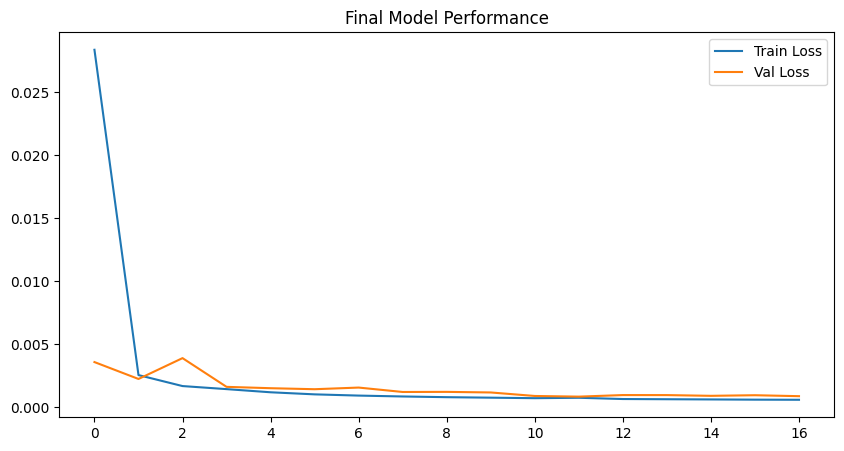

937/937 ━━━━━━━━━━━━━━━━━━━━ 42s 44ms/step
Refined Threshold: 0.031144165768100016


In [5]:
# 1. Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 2. Training
print("Training starting (Max 50 epochs)...")
history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# 3. Plotting results
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Final Model Performance')
plt.legend()
plt.show()

# 4. Threshold Calculation
X_train_pred = model.predict(X_train)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train), axis=(1, 2))
threshold = np.mean(train_mae_loss) + 3 * np.std(train_mae_loss)
print(f"Refined Threshold: {threshold}")

Starting memory-efficient prediction... (It won't crash now)


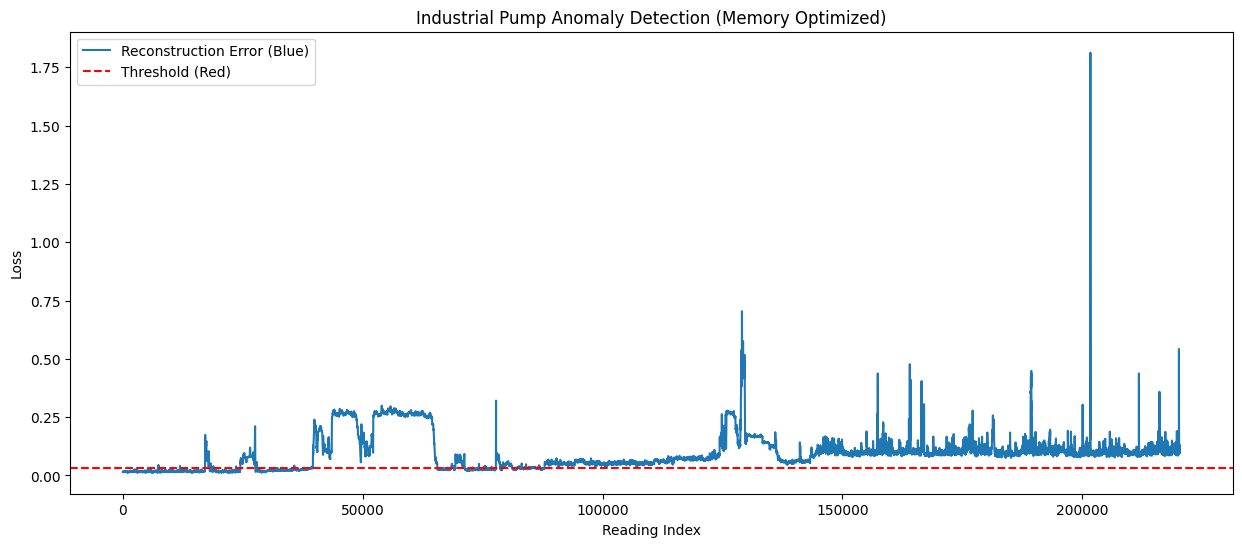

✅ Success! Anomalies Detected: 172687


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Memory bachane ke liye function jo thora thora data process kare
def predict_in_chunks(model, data, window_size=30, chunk_size=50000):
    predictions = []
    for i in range(0, len(data) - window_size, chunk_size):
        end_idx = min(i + chunk_size + window_size, len(data))
        # Chunk nikalna
        chunk = data[i:end_idx]
        # Sequences banana (Sirf is chunk ke liye)
        X_chunk = []
        for j in range(len(chunk) - window_size):
            X_chunk.append(chunk[j : (j + window_size)])
        X_chunk = np.array(X_chunk)

        # Predict aur error nikalna
        preds = model.predict(X_chunk, verbose=0)
        mae = np.mean(np.abs(preds - X_chunk), axis=(1, 2))
        predictions.extend(mae)
    return np.array(predictions)

print("Starting memory-efficient prediction... (It won't crash now)")

# 2. Prediction Run karein
try:
    test_mae_loss = predict_in_chunks(model, df_test_scaled)

    # 3. Score DataFrame (Index adjust karna parega prediction length ke mutabiq)
    test_score_df = pd.DataFrame(index=df[:len(test_mae_loss)].index)
    test_score_df['loss'] = test_mae_loss
    test_score_df['threshold'] = threshold
    test_score_df['anomaly'] = test_score_df.loss > test_score_df.threshold

    # 4. Final Plot
    plt.figure(figsize=(15, 6))
    plt.plot(test_score_df.index, test_score_df.loss, label='Reconstruction Error (Blue)')
    plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold (Red)')
    plt.title('Industrial Pump Anomaly Detection (Memory Optimized)')
    plt.xlabel('Reading Index')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    print(f"✅ Success! Anomalies Detected: {test_score_df['anomaly'].sum()}")

except Exception as e:
    print(f"❌ Error occurred: {e}")

In [7]:
# Model ko .h5 format mein save karna
model.save('industrial_pump_best_model.h5')

# Laptop mein download karna
from google.colab import files
files.download('industrial_pump_best_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>